<a href="https://colab.research.google.com/github/GreekGodOfStats/NBA/blob/main/PLAYER_TRACKING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**INSTALLS**

---



In [1]:
!pip install -q gdown
!pip install -q inference-gpu

!pip install supervision==0.27.0
!pip install -q git+https://github.com/roboflow/sports.git@feat/basketball

!pip install -q transformers num2words
!pip install roboflow
# !pip install -q flash-attn --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 7.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 38.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 86.

**IMPORTS**

---



In [2]:
import os
from google.colab import userdata
from pathlib import Path
from IPython.display import Video
from typing import Dict, List, Optional, Union, Iterable, Tuple
from operator import itemgetter
from roboflow import Roboflow

import cv2
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from google.colab import files

import bs4
import requests
import time
import glob
from time import sleep
from requests.adapters import HTTPAdapter
from requests.packages.urllib3.util.retry import Retry
from sklearn import linear_model
from bs4 import BeautifulSoup

import supervision as sv
from inference import get_model
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer
)
from sports.basketball import (
    CourtConfiguration,
    League,
    draw_court,
    draw_points_on_court,
    draw_paths_on_court,
    draw_made_and_miss_on_court,
    ShotEventTracker
)

ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM2 model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM2_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL

**ENVIRONMENT VARIABLES**

---



In [3]:
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")
HOME = Path.cwd()
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "[CUDAExecutionProvider]"

In [4]:
os.environ["ROBOFLOW_API_KEY"]

'ui4ZSPXoyNK5vpqzpoup'

**GPU AVAILABILITY**

---



In [5]:
!nvidia-smi

Sat Dec 27 19:20:13 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             12W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**SAM2 SETUP**

---



In [6]:
!git clone https://github.com/Gy920/segment-anything-2-real-time.git
%cd {HOME}/segment-anything-2-real-time
!pip install -e . -q
!python setup.py build_ext --inplace

!(cd checkpoints && bash download_ckpts.sh)

Cloning into 'segment-anything-2-real-time'...
remote: Enumerating objects: 406, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 406 (delta 65), reused 56 (delta 56), pack-reused 314 (from 2)
Receiving objects: 100% (406/406), 79.43 MiB | 27.37 MiB/s, done.
Resolving deltas: 100% (91/91), done.
/content/segment-anything-2-real-time
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.0 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
running build_ext
W1227 19:26:21.734000 3696 torch/utils/cpp_extension.py:521] The detected CUDA version (12.5) has a minor version mi

**VIDEOS**

---



In [7]:
SOURCE_VIDEO_DIRECTORY = HOME / "source"
!gdown -q https://drive.google.com/drive/folders/1eDJYqQ77Fytz15tKGdJCMeYSgmoQ-2-H -O {SOURCE_VIDEO_DIRECTORY} --folder
!ls -la {SOURCE_VIDEO_DIRECTORY}

total 73108
drwxr-xr-x 2 root root     4096 Dec 27 19:28 .
drwxr-xr-x 1 root root     4096 Dec 27 19:28 ..
-rw-r--r-- 1 root root  8297338 May 20  2025 boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4
-rw-r--r-- 1 root root  6596558 May 20  2025 boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4
-rw-r--r-- 1 root root 10443619 May 20  2025 boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4
-rw-r--r-- 1 root root  6156208 May 20  2025 boston-celtics-new-york-knicks-game-1-q1-04.44-04.39.mp4
-rw-r--r-- 1 root root  5251332 May 20  2025 boston-celtics-new-york-knicks-game-1-q1-05.13-05.09.mp4
-rw-r--r-- 1 root root  7956046 May 20  2025 boston-celtics-new-york-knicks-game-1-q1-06.00-05.54.mp4
-rw-r--r-- 1 root root  9276239 May 20  2025 boston-celtics-new-york-knicks-game-1-q1-07.41-07.34.mp4
-rw-r--r-- 1 root root  7319631 May 20  2025 boston-celtics-new-york-knicks-game-1-q2-08.09-08.03.mp4
-rw-r--r-- 1 root root  8770496 May 20  2025 boston-celtics-new-york-knicks-g

In [8]:
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4"

**ROSTER DIM**

---



In [9]:
TEAM_ROSTERS = {
  "New York Knicks": {
    "55": "Hukporti",
    "1": "Payne",
    "0": "Wright",
    "11": "Brunson",
    "3": "Hart",
    "32": "Towns",
    "44": "Shamet",
    "25": "Bridges",
    "2": "McBride",
    "23": "Robinson",
    "8": "Anunoby",
    "4": "Dadiet",
    "5": "Achiuwa",
    "13": "Kolek"
  },
  "Boston Celtics": {
    "42": "Horford",
    "55": "Scheierman",
    "9": "White",
    "20": "Davison",
    "7": "Brown",
    "0": "Tatum",
    "27": "Walsh",
    "4": "Holiday",
    "8": "Porzingis",
    "40": "Kornet",
    "88": "Queta",
    "11": "Pritchard",
    "30": "Hauser",
    "12": "Craig",
    "26": "Tillman"
  }
}

TEAM_COLORS = {
    "New York Knicks": "#006BB6",
    "Boston Celtics": "#007A33"
}

In [10]:
def get_rosters(gameid):
  headers = {
'Accept': '*/*',
'Accept-Encoding': 'gzip, deflate, br, zstd',
'Accept-Language': 'en-US,en;q=0.9',
'Connection': 'keep-alive',
'Host': 'stats.nba.com',
'Origin': 'https://www.nba.com',
'Referer': 'https://www.nba.com/',
'Sec-Fetch-Dest': 'empty',
'Sec-Fetch-Mode': 'cors',
'Sec-Fetch-Site': 'same-site',
'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/138.0.0.0 Safari/537.36 Edg/138.0.0.0',
'sec-ch-ua': '"Not)A;Brand";v="8", "Chromium";v="138", "Microsoft Edge";v="138"',
'sec-ch-ua-mobile': '?0',
'sec-ch-ua-platform': '"Windows"'
  }

  url = f"https://stats.nba.com/stats/boxscoretraditionalv2?EndPeriod=10&EndRange=28800&GameID={gameid}&RangeType=0&Season=2024-25&SeasonType=Playoffs&StartPeriod=1&StartRange=0"
  r = requests.get(url, headers=headers).json()

  df = pd.DataFrame(r['resultSets'][0]['rowSet'], columns = r['resultSets'][0]['headers'])
  #return df.columns
  df['Played'] = df['COMMENT'].apply(lambda x: 'DNP' not in x)
  df = df[df['Played'] == True]
  df = df[['GAME_ID','TEAM_ID','TEAM_ABBREVIATION','PLAYER_ID']]

  season = str(int(gameid[3:5]) + 2000) + '-' + str(int(gameid[3:5]) + 1)
  rosters = []
  for teamid in df['TEAM_ID'].drop_duplicates():
    url = f"https://stats.nba.com/stats/commonteamroster?LeagueID=00&Season={season}&TeamID={teamid}"
    r = requests.get(url, headers=headers).json()
    data = pd.DataFrame(r['resultSets'][0]['rowSet'], columns = r['resultSets'][0]['headers'])
    data = data[['TeamID','PLAYER_ID','NUM']]
    rosters.append(data)

  roster = pd.concat(rosters)
  df = df.merge(roster,'left',left_on=['TEAM_ID','PLAYER_ID'],right_on=['TeamID','PLAYER_ID'])
  df['NUM'] = df['NUM'].astype(int)
  return df

In [87]:
#get_rosters('0042400211')

**PLAYER DETECTION**

---



In [11]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
#PLAYER_DETECTION_MODEL_ID = "basketball-object-detection-fv4kw/2"
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.4
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID,api_key=os.environ["ROBOFLOW_API_KEY"])
#"basketball-object-detection-fv4kw/2"
#"ui4ZSPXoyNK5vpqzpoup"

#Variable that is solely for drawing boxes
COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

Resolved model_id: basketball-player-detection-3-ycjdo/4, dataset_id: basketball-player-detection-3-ycjdo, version_id: 4


**PLOT LOCATIONS OF DETECTED OBJECTS IN A FRAME**

---



In [ ]:
#box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
#label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
#frame = next(frame_generator)

frames = []
i = 1
for frame in frame_generator:
  result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
  detections = sv.Detections.from_inference(result)
  xy = detections.xyxy
  x1 = [i[0] for i in detections.xyxy]
  y1 = [i[1] for i in detections.xyxy]
  x2 = [i[2] for i in detections.xyxy]
  y2 = [i[3] for i in detections.xyxy]
  conf = detections.confidence
  class_id = detections.class_id
  class_name = detections.data['class_name']
  #print(xy)
  df = pd.DataFrame(list(zip(x1, y1, x2, y2, conf, class_id, class_name)),
                columns =['x1', 'y1', 'x2', 'y2', 'confidence', 'class_id', 'class_name'])
  df = df[df['confidence'] >= 0.75]
  df['Video'] = SOURCE_VIDEO_PATH
  df['FrameOrder'] = i
  frames.append(df)
  i = i+1

data = pd.concat(frames)
data.to_csv(f"C:\\Users\\gregs\\Other\\trackingtestdata.csv")
files.download(f"C:\\Users\\gregs\\Other\\trackingtestdata.csv")


KeyboardInterrupt: 

**DEFINITIONS OF OBJECT-CLASS GROUPS**


---



In [12]:
NUMBER_CLASS_ID = 2
PLAYER_CLASS_IDS = [3, 4, 5, 6, 7] # player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block

**LOAD SAM2**

---



In [13]:
!pip install sam2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.8/152.8 kB 7.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for sam2: filename=sam2-1.1.0-cp312-cp312-linux_x86_64.whl size=501978 sha256=4799be8e82612826923d03b1cb403b8d9d2a1d07ab945d2b736fff4c29c864b0
  Stored in directory: /root/.cache/pip/wheels/22/cb/54/0351e695a7a2e8eed8d5987cd02d8e5227eec87b0bbcc00094
Successfully built sam2


In [14]:
%cd $HOME/segment-anything-2-real-time

from sam2.build_sam import build_sam2_camera_predictor

SAM2_CHECKPOINT = "checkpoints/sam2.1_hiera_large.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_camera_predictor(SAM2_CONFIG, SAM2_CHECKPOINT)

/content/segment-anything-2-real-time


**FUNCTIONS FOR TRACKING THROUGH VIDEO**

---



In [15]:
from __future__ import annotations

class SAM2Tracker:
    def __init__(self, predictor) -> None:
        self.predictor = predictor
        self._prompted = False

    def prompt_first_frame(self, frame: np.ndarray, detections: sv.Detections) -> None:
        if len(detections) == 0:
            raise ValueError("detections must contain at least one box")

        if detections.tracker_id is None:
            detections.tracker_id = list(range(1, len(detections) + 1))

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            self.predictor.load_first_frame(frame)
            for xyxy, obj_id in zip(detections.xyxy, detections.tracker_id):
                bbox = np.asarray([xyxy], dtype=np.float32)
                self.predictor.add_new_prompt(
                    frame_idx=0,
                    obj_id=int(obj_id),
                    bbox=bbox,
                )

        self._prompted = True

    def propagate(self, frame: np.ndarray) -> sv.Detections:
        if not self._prompted:
            raise RuntimeError("Call prompt_first_frame before propagate")

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            tracker_ids, mask_logits = self.predictor.track(frame)

        tracker_ids = np.asarray(tracker_ids, dtype=np.int32)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)

        if masks.ndim == 2:
            masks = masks[None, ...]

        masks = np.array([
            sv.filter_segments_by_distance(mask, relative_distance=0.03, mode="edge")
            for mask in masks
        ])

        xyxy = sv.mask_to_xyxy(masks=masks)
        detections = sv.Detections(xyxy=xyxy, mask=masks, tracker_id=tracker_ids)
        return detections

    def reset(self) -> None:
        self._prompted = False

In [16]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-mask{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

# we use RF-DETR model to aquire future SAM2 prompt

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

#annotated_frame = frame.copy()
#annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
#sv.plot_image(annotated_frame)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)


**LOAD MODEL FOR RECOGNIZING JERSEY NUMBERS**

---



In [17]:
NUMBER_RECOGNITION_MODEL_ID = "basketball-jersey-numbers-ocr/3"
NUMBER_RECOGNITION_MODEL = get_model(model_id=NUMBER_RECOGNITION_MODEL_ID,api_key=os.environ["ROBOFLOW_API_KEY"])
NUMBER_RECOGNITION_MODEL_PROMPT = "Read the number."

Resolved model_id: basketball-jersey-numbers-ocr/3, dataset_id: basketball-jersey-numbers-ocr, version_id: 3


Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

**FILTER FOR ONLY PLAYER-NUMBER MATCHES ABOVE THE THRESHOLD**

---



In [18]:
def coords_above_threshold(
    matrix: np.ndarray, threshold: float, sort_desc: bool = True
) -> List[Tuple[int, int]]:
    """
    Return all (row_index, col_index) where value > threshold.
    Rows and columns may repeat.
    Optionally sort by value descending.
    """
    A = np.asarray(matrix)
    rows, cols = np.where(A > threshold)
    pairs = list(zip(rows.tolist(), cols.tolist()))
    if sort_desc:
        pairs.sort(key=lambda rc: A[rc[0], rc[1]], reverse=True)
    return pairs

**LOAD COURT KEYPOINT DETECTION MODEL**

---



In [92]:
KEYPOINT_DETECTION_MODEL_ID = "basketball-court-detection-2/14"
KEYPOINT_DETECTION_MODEL_CONFIDENCE = 0.3
KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE = 0.5
KEYPOINT_DETECTION_MODEL = get_model(model_id=KEYPOINT_DETECTION_MODEL_ID,api_key=os.environ["ROBOFLOW_API_KEY"])
KEYPOINT_COLOR = sv.Color.from_hex('#FF1493')

Resolved model_id: basketball-court-detection-2/14, dataset_id: basketball-court-detection-2, version_id: 14


### **PROCESS FRAMES**


---



In [94]:
STRIDE = 30

crops = []
i = 1

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
#len([frame for frame in frame_generator])
for frame in [i for i in frame_generator][:1]:
  frame_h, frame_w, *_ = frame.shape
  ###     DETECT AND LOCATE PLAYERS
  result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD, class_agnostic_nms=True)[0]
  detections = sv.Detections.from_inference(result)
  detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
  detections.mask = sv.xyxy_to_mask(boxes=detections.xyxy, resolution_wh=(frame_w, frame_h))
  #print(detections)
  ###     CLASSIFY WHICH TEAM EACH PLAYER BELONGS WITH
  boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
  for box in boxes:
      crops.append(sv.crop_image(frame, box))
  team_classifier = TeamClassifier(device="cuda")
  team_classifier.fit(crops)
  teams = team_classifier.predict(crops)
  #print(teams)
  xy = detections.xyxy
  x1 = [i[0] for i in detections.xyxy]
  y1 = [i[1] for i in detections.xyxy]
  x2 = [i[2] for i in detections.xyxy]
  y2 = [i[3] for i in detections.xyxy]
  conf = detections.confidence
  class_id = detections.class_id
  class_name = detections.data['class_name']
  #print(xy)

  ###     DETECT AND RECOGNIZE JERSEY NUMBERS
  frame_h, frame_w, *_ = frame.shape

  numresult = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
  numdetections = sv.Detections.from_inference(numresult)
  numdetections = numdetections[numdetections.class_id == NUMBER_CLASS_ID]

  crops = [
    sv.resize_image(sv.crop_image(frame, xyxy), resolution_wh=(224, 224))
    for xyxy
    in sv.clip_boxes(sv.pad_boxes(xyxy=numdetections.xyxy, px=10, py=10), (frame_w, frame_h))
  ]
  numbers = [
      NUMBER_RECOGNITION_MODEL.predict(crop, NUMBER_RECOGNITION_MODEL_PROMPT)[0]
      for crop
      in crops
  ]
  num_xy = numdetections.xyxy
  num_x1 = [i[0] for i in numdetections.xyxy]
  num_y1 = [i[1] for i in numdetections.xyxy]
  num_x2 = [i[2] for i in numdetections.xyxy]
  num_y2 = [i[3] for i in numdetections.xyxy]
  num_conf = numdetections.confidence
  num_class_id = numdetections.class_id
  num_class_name = numdetections.data['class_name']
  numdf = pd.DataFrame(list(zip(num_x1, num_y1, num_x2, num_y2, num_conf, num_class_id, num_class_name,numbers)),
                columns =['x1', 'y1', 'x2', 'y2', 'confidence', 'class_id', 'class_name','number'])
  numdf = numdf[numdf['confidence'] >= 0.75]
  numdf['number'] = numdf['number'].astype(int)
  numdf['Video'] = SOURCE_VIDEO_PATH
  numdf['FrameOrder'] = i


###     MATCH PAIRINGS OF PLAYER AND JERSEY NUMBER
  numdetections.mask = sv.xyxy_to_mask(boxes=numdetections.xyxy, resolution_wh=(frame_w, frame_h))
  # we use mask IoS to match numbers with players
  iou = sv.mask_iou_batch(
      masks_true=detections.mask,
      masks_detection=numdetections.mask,
      overlap_metric=sv.OverlapMetric.IOS
  )

  pairs = coords_above_threshold(iou, 0.9)
  player_idx, number_idx = zip(*pairs)

  pairs


###     DETECT KEYPOINTS ON THE COURT
  config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
  result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
  key_points = sv.KeyPoints.from_inference(result)
  landmarks_mask = key_points.confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

  if np.count_nonzero(landmarks_mask) >= 4:

      # we calculate homography matrix

      court_landmarks = np.array(config.vertices)[landmarks_mask]
      frame_landmarks = key_points[:, landmarks_mask].xy[0]

      frame_to_court_transformer = ViewTransformer(
          source=frame_landmarks,
          target=court_landmarks,
      )

      frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

      if len(frame_xy) > 0:

          # we transform points

          court_xy = frame_to_court_transformer.transform_points(points=frame_xy)


  #print(detections,numbers)
  df = pd.DataFrame(list(zip(x1, y1, x2, y2, conf, class_id, class_name,teams)),
                columns =['x1', 'y1', 'x2', 'y2', 'confidence', 'class_id', 'class_name','team'])
  df = df[df['confidence'] >= 0.75]
  df['Video'] = SOURCE_VIDEO_PATH
  df['FrameOrder'] = i

  #i = i + 1



Embedding extraction: 1it [00:00,  5.40it/s]
Embedding extraction: 1it [00:00,  7.55it/s]


In [98]:
frame_xy
pd.DataFrame(frame_xy)
pd.DataFrame(court_xy)
########## THESE FRAMES WILL HAVE THE SAME INDEX AS DF ABOVE. WE SIMPLY NEED TO REINDEX AND JOIN ON INDEX
##########     We then need to do something similar for ball and for rim. Start with "ball_xy" in place of "frame_xy" and then convert, same for rim

,0,1
0,87.484276,40.284924
1,73.183754,30.592838
2,64.689041,37.294930
3,76.484688,3.072864
4,82.471809,49.565098
5,59.468403,32.922585
6,87.210770,28.681652
7,60.035999,37.748848
8,83.951576,42.119289
9,79.722939,12.995662


In [45]:
pairsdf = pd.DataFrame(pairs,columns = ['PlayerIndex','NumberIndex'])
df = df.reset_index()
copy = df.copy()
num = numdf.reset_index()
df = df.merge(pairsdf,'left',left_on = ['index'],right_on=['PlayerIndex']).merge(num,'left',left_on=['NumberIndex'],right_on = ['index'])
df = df[['x1_x','y1_x','x2_x','y2_x','confidence_x','class_id_x','class_name_x','team','number','Video_x','FrameOrder_x']]
df.columns = [c.replace('_x','') for c in df.columns]

In [89]:
#df.reset_index(inplace = True)
df['Players'] = df.groupby(['team'])['index'].transform('nunique')
df['Jerseys'] = df.groupby(['team'])['number'].transform('nunique')
df['DupeJersey'] = df.groupby(['team','number'])['index'].transform('nunique')
df['MaxDupeJersey'] = df['DupeJersey'].max()
df['FiveOnEachTeam'] = (df['Players'] == 5).all() & (df['MaxDupeJersey'] == 1).all()
df['BestRep'] = df['Jerseys'].max()
df['Use'] = np.where(df['FiveOnEachTeam'] == True,True,np.where(df['Jerseys'] == df['BestRep'],True,False))


t0 = df[(df['team'] == 0) & (df['number'].isna() == False)][['team','number','Use']].drop_duplicates()
t1 = df[(df['team'] == 1) & (df['number'].isna() == False)][['team','number','Use']].drop_duplicates()
r = get_rosters('0042400211')
r['TmRk'] = r['TeamID'].rank(method='dense')
r1 = r[r['TmRk'] == 1]
r2 = r[r['TmRk'] == 2]
team0 = t0.merge(r,left_on='number',right_on='NUM')
team0['Jerseys'] = team0['number'].nunique()
team0['Matched'] = team0.groupby(['TeamID'])['number'].transform('nunique')
team0['BestMatch'] = team0.groupby(['GAME_ID'])['Matched'].transform('max')
team0['Selected'] = np.where(team0['Matched'] == team0['Jerseys'],1,np.where(team0['Matched'] == team0['BestMatch'],0,-1))
team0 = team0[team0['Selected'] != (-1)]

team1 = t1.merge(r,left_on='number',right_on='NUM')
team1['Jerseys'] = team1['number'].nunique()
team1['Matched'] = team1.groupby(['TeamID'])['number'].transform('nunique')
team1['BestMatch'] = team1.groupby(['GAME_ID'])['Matched'].transform('max')
team1['Selected'] = np.where(team1['Matched'] == team1['Jerseys'],1,np.where(team1['Matched'] == team1['BestMatch'],0,-1))
team1 = team1[team1['Selected'] != (-1)]
confirmed = pd.concat([team0,team1])
confirmed = confirmed[(confirmed['Use'] == True) & (confirmed['Selected'] == 1)]
confirmedteams = confirmed[['team','TEAM_ID']].drop_duplicates()
if len(confirmedteams) == 2:
  roster = confirmed
elif len(confirmedteams) == 1:
  confirmedteams['CONF_TEAM'] = confirmedteams['team']
  confirmedteams['CONF_TEAM_ID'] = confirmedteams['TEAM_ID']
  inferred = poss.merge(confirmedteams,'left',on=['team']).merge(confirmedteams,'left',left_on=['TEAM_ID_x'],right_on=['TEAM_ID'])
  inferred = inferred[(inferred['CONF_TEAM_x'].isna()) & (inferred['CONF_TEAM_ID_y'].isna())][['team_x','TEAM_ID_x']]
  inferred.columns = [c.replace('_x','') for c in inferred.columns]
  roster = pd.concat([confirmedteams,inferred])[['team','TEAM_ID']]


In [99]:
#inferred = poss.merge(confirmedteams,'left',on=['team']).merge(confirmedteams,'left',left_on=['TEAM_ID_x'],right_on=['TEAM_ID'])
#inferred = inferred[(inferred['CONF_TEAM_x'].isna()) & (inferred['CONF_TEAM_ID_y'].isna())][['team_x','TEAM_ID_x']]
#inferred.columns = [c.replace('_x','') for c in inferred.columns]
roster

########## NOW THAT TEAM MAPPINGS ARE CONFIRMED, WE CAN LOOKUP PLAYER IDENTITIES IN "r"  based on TEAM_ID and number = NUM

,team,TEAM_ID
0,1,1610612752
3,0,1610612738




---


# **THE END**   🏀


---










---



---



---



---



### Single frame keypoint detection

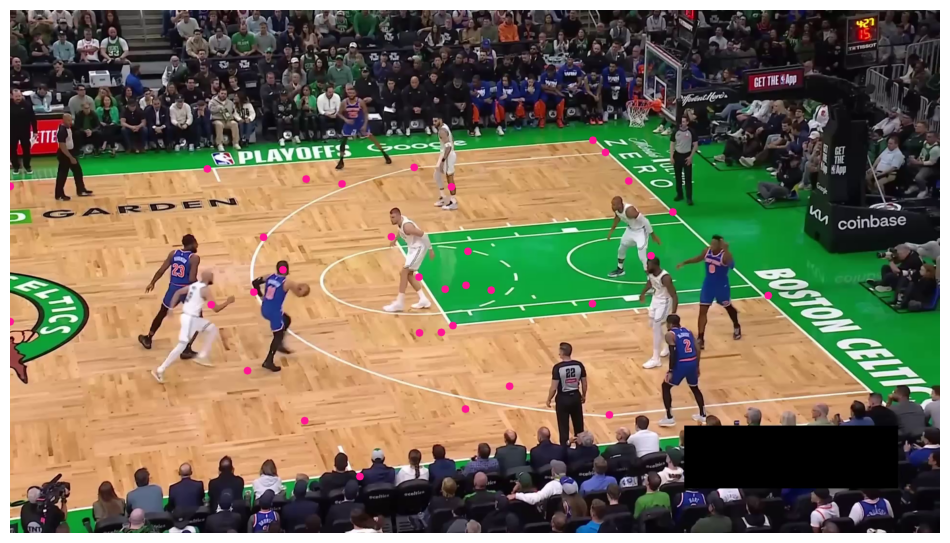

In [ ]:
vertex_annotator = sv.VertexAnnotator(color=KEYPOINT_COLOR, radius=8)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=key_points)

sv.plot_image(annotated_frame)

### Detecting keypoints with high confidence

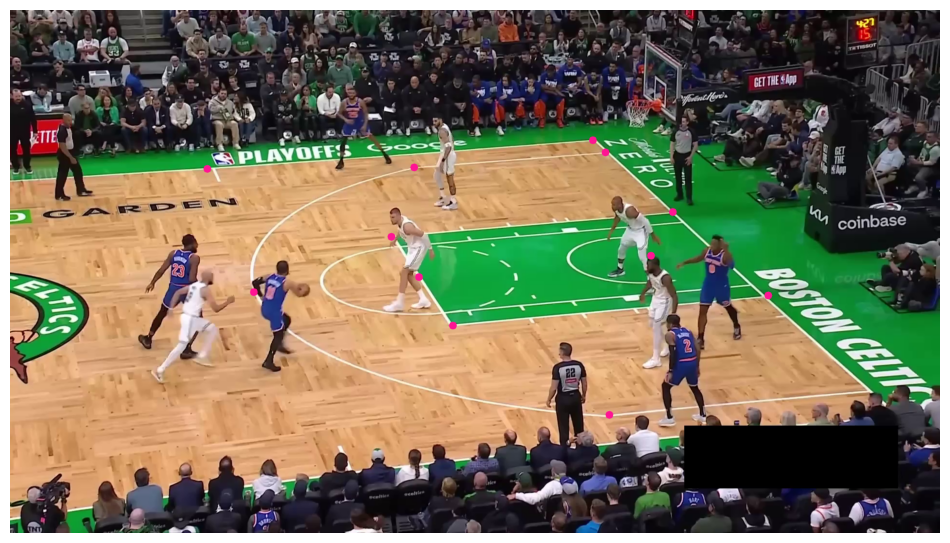

In [ ]:
vertex_annotator = sv.VertexAnnotator(color=KEYPOINT_COLOR, radius=8)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
key_points = key_points[:, key_points.confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE]

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=key_points)

sv.plot_image(annotated_frame)

## Map player positions to court coordinates

### Single frame player position mapping

Embedding extraction: 1it [00:00, 17.67it/s]


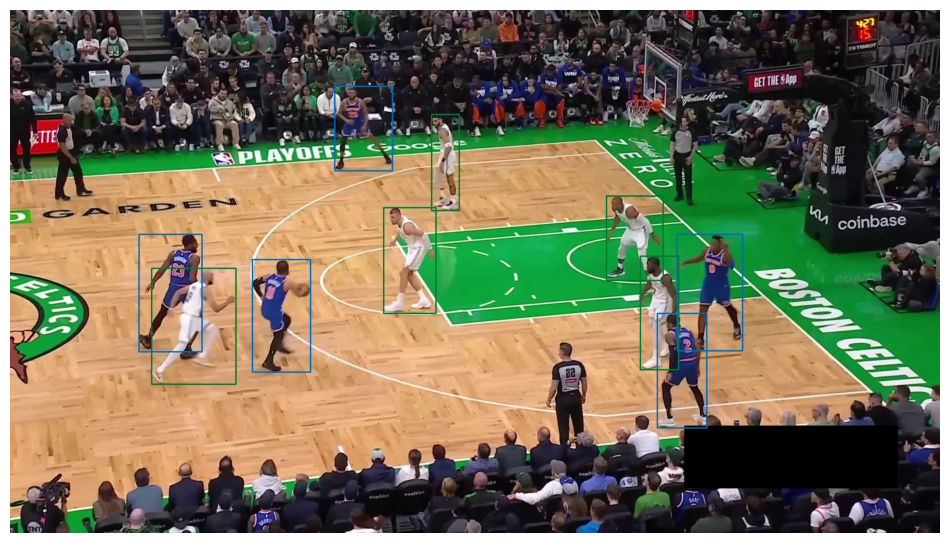

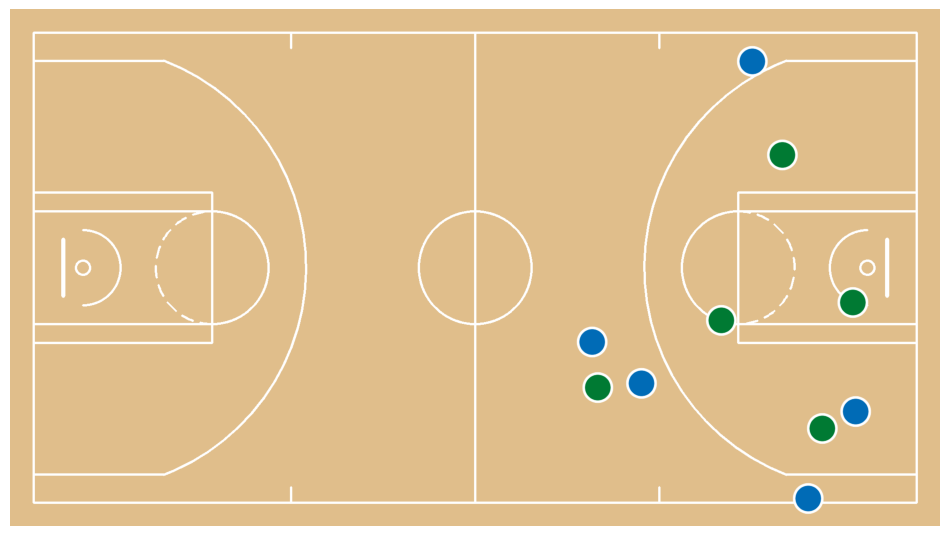

In [ ]:
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# define team annotators

team_colors = sv.ColorPalette.from_hex([
    TEAM_COLORS[TEAM_NAMES[0]],
    TEAM_COLORS[TEAM_NAMES[1]]
])

team_box_annotator = sv.BoxAnnotator(
    color=team_colors,
    thickness=2,
    color_lookup=sv.ColorLookup.INDEX
)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

annotated_frame = frame.copy()
annotated_frame = team_box_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    custom_color_lookup=TEAMS[detections.tracker_id - 1]
)
sv.plot_image(annotated_frame)

# we use a keypoint model to detect court landmarks

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
landmarks_mask = key_points.confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

if np.count_nonzero(landmarks_mask) >= 4:

    # we calculate homography matrix

    court_landmarks = np.array(config.vertices)[landmarks_mask]
    frame_landmarks = key_points[:, landmarks_mask].xy[0]

    frame_to_court_transformer = ViewTransformer(
        source=frame_landmarks,
        target=court_landmarks,
    )

    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

    if len(frame_xy) > 0:

        # we transform points

        court_xy = frame_to_court_transformer.transform_points(points=frame_xy)

        # we visualize the results

        court = draw_court(config=config)
        court = draw_points_on_court(
            config=config,
            xy=court_xy[TEAMS == 0],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[0]]),
            court=court
        )
        court = draw_points_on_court(
            config=config,
            xy=court_xy[TEAMS == 1],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[1]]),
            court=court
        )

        sv.plot_image(court)

### Full video player position mapping

In [ ]:
video_xy = []

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tacks across all video frames

for frame_idx, frame in tqdm(enumerate(frame_generator)):
    detections = tracker.propagate(frame)

    # we use a keypoint model to detect court landmarks

    result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
    key_points = sv.KeyPoints.from_inference(result)
    landmarks_mask = key_points.confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

    if np.count_nonzero(landmarks_mask) >= 4:

        # we calculate homography matrix

        court_landmarks = np.array(config.vertices)[landmarks_mask]
        frame_landmarks = key_points[:, landmarks_mask].xy[0]

        frame_to_court_transformer = ViewTransformer(
            source=frame_landmarks,
            target=court_landmarks,
        )

        frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

        # transform video frame coordinates into court coordinates

        court_xy = frame_to_court_transformer.transform_points(points=frame_xy)
        video_xy.append(court_xy)

video_xy = np.array(video_xy)

Embedding extraction: 1it [00:00, 18.17it/s]
237it [01:39,  2.39it/s]


In [ ]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-map{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
court = draw_court(config=config)
court_h, court_w, _ = court.shape

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_info.width = court_w
video_info.height = court_h

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame_xy in tqdm(video_xy):
        court = draw_court(config=config)
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 0],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[0]]),
            court=court
        )
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 1],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[1]]),
            court=court
        )

        sink.write_frame(court)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}

100%|██████████| 237/237 [00:09<00:00, 25.08it/s]


In [ ]:
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)

### Clean player movement paths

We are detecting sudden jumps in position using robust speed analysis. We are removing short abnormal runs and nearby frames to eliminate teleport-like artifacts. We are filling missing segments with linear interpolation to ensure continuous motion. We are smoothing all paths with a Savitzky–Golay filter to achieve stable and natural movement.

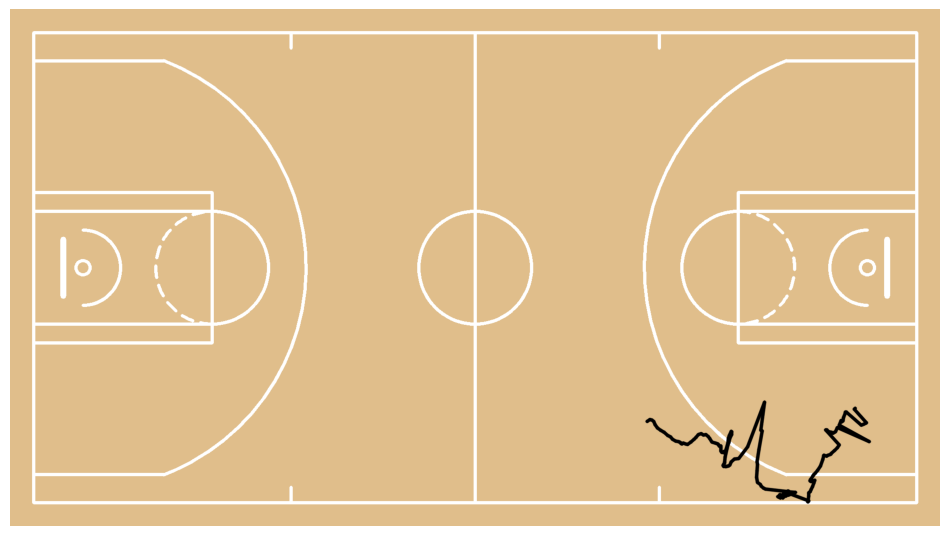

In [ ]:
court = draw_paths_on_court(
    config=config,
    paths=[video_xy[:, 0, :]],
)

sv.plot_image(court)

In [ ]:
cleaned_xy, edited_mask = clean_paths(
    video_xy,
    jump_sigma=3.5,
    min_jump_dist=0.6,
    max_jump_run=18,
    pad_around_runs=2,
    smooth_window=9,
    smooth_poly=2,
)

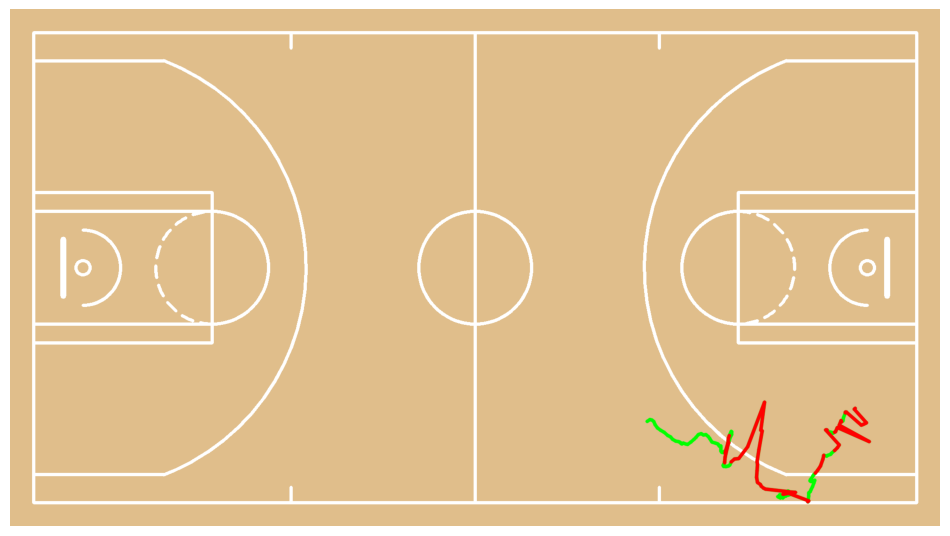

In [ ]:
def split_true_runs(mask: np.ndarray, coords: np.ndarray) -> list[np.ndarray]:
    mask = mask.squeeze()
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return []
    splits = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, splits)
    return [coords[g, 0, :] for g in groups]


court = draw_paths_on_court(
    config=config,
    paths=[video_xy[:, 0, :]],
    color=sv.Color.GREEN,
)

court = draw_paths_on_court(
    config=config,
    paths=split_true_runs(edited_mask[:, 0], video_xy),
    color=sv.Color.RED,
    court=court
)

sv.plot_image(court)

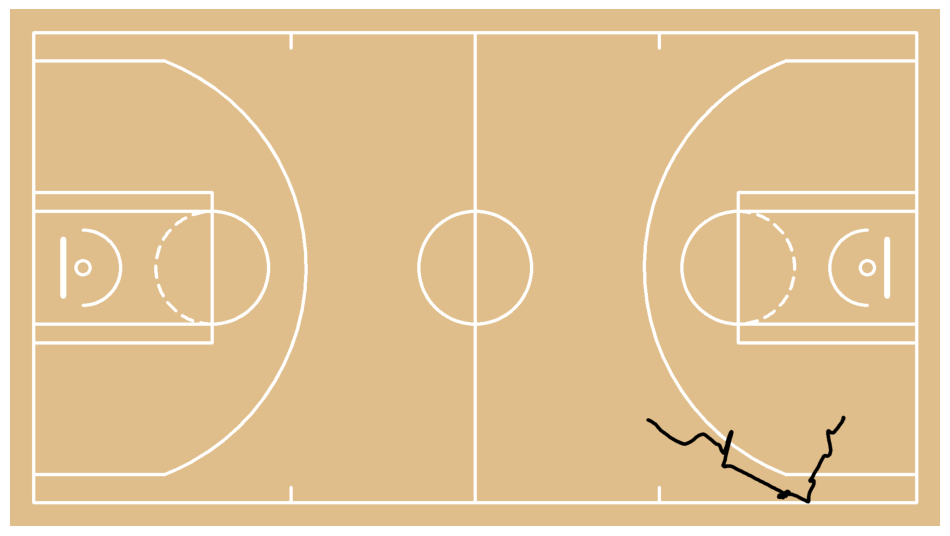

In [ ]:
test = draw_paths_on_court(
    config=config,
    paths=[cleaned_xy[:, 0, :]],
)

sv.plot_image(test)

In [ ]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-map{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
court = draw_court(config=config)
court_h, court_w, _ = court.shape

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_info.width = court_w
video_info.height = court_h

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame_xy in tqdm(cleaned_xy):
        court = draw_court(config=config)
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 0],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[0]]),
            court=court
        )
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 1],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[1]]),
            court=court
        )

        sink.write_frame(court)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}

100%|██████████| 237/237 [00:09<00:00, 25.14it/s]


In [ ]:
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)

## Classify shorts as made or miss

### Keep only "player-jump-shot" class

In [ ]:
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4"

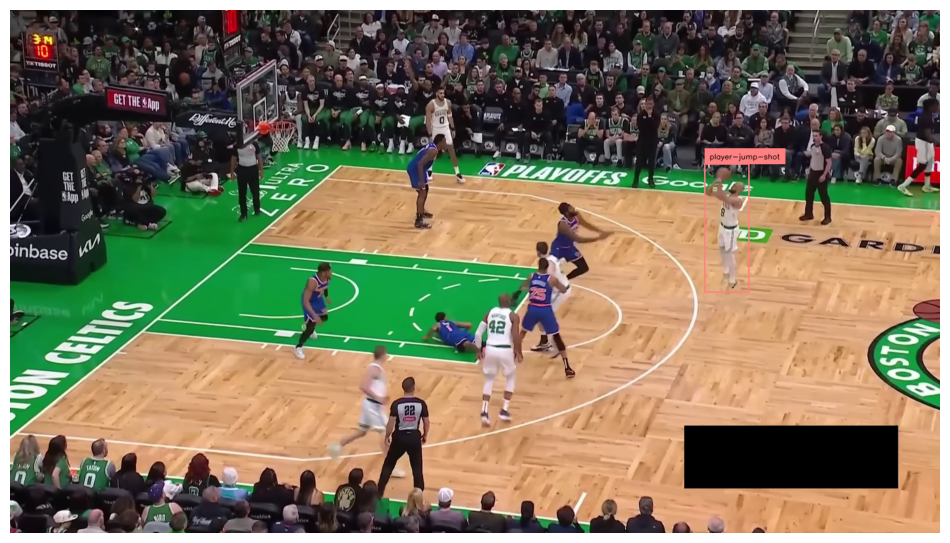

In [ ]:
PLAYER_JUMP_SHOT_CLASS_ID = 5
FRAME_IDX = 65

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX, iterative_seek=True)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

### Mark jump-shot location on the court

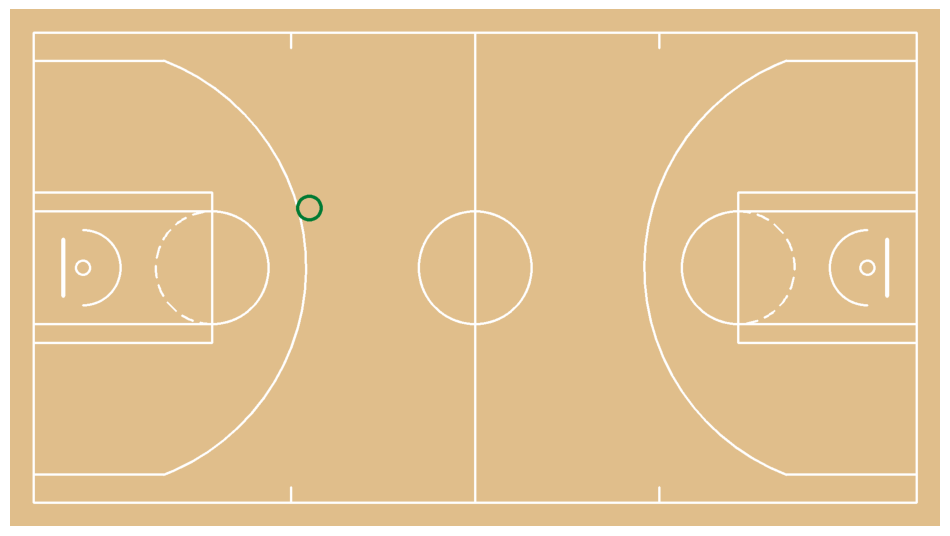

In [ ]:
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX, iterative_seek=True)
frame = next(frame_generator)

# we use a RF-DETR model to detect players

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

# we use a keypoint model to detect court landmarks

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
landmarks_mask = key_points.confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

if np.count_nonzero(landmarks_mask) >= 4:

    # we calculate homography matrix

    court_landmarks = np.array(config.vertices)[landmarks_mask]
    frame_landmarks = key_points[:, landmarks_mask].xy[0]

    frame_to_court_transformer = ViewTransformer(
        source=frame_landmarks,
        target=court_landmarks,
    )

    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

    # transform video frame coordinates into court coordinates

    court_xy = frame_to_court_transformer.transform_points(points=frame_xy)

    court = draw_made_and_miss_on_court(
        config=config,
        made_xy=court_xy,
        made_size=25,
        made_color=sv.Color.from_hex("#007A33"),
        made_thickness=6,
        line_thickness=4
    )

    sv.plot_image(court)

## Detect shot events

[{'event': 'START', 'frame': 64, 'type': 'JUMP'}]


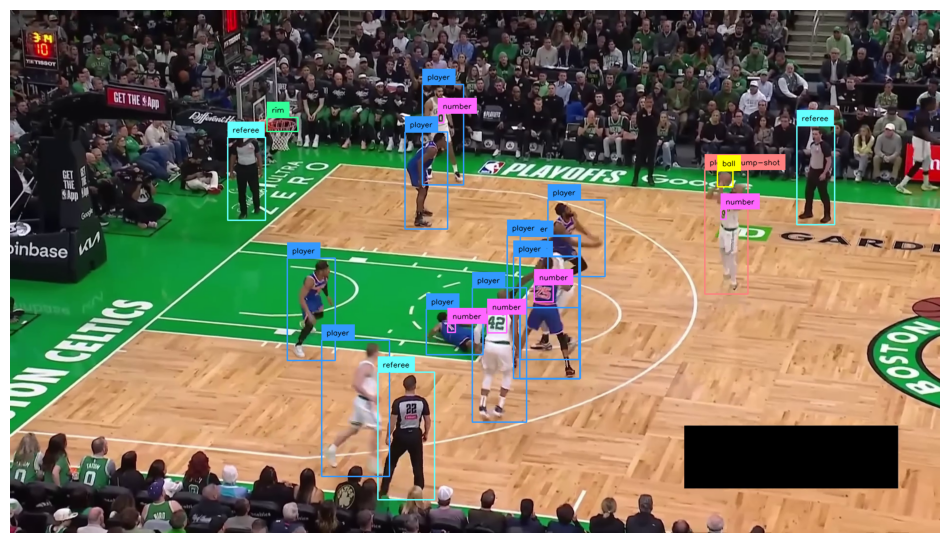

[{'event': 'MISSED', 'frame': 115, 'type': 'JUMP'}]


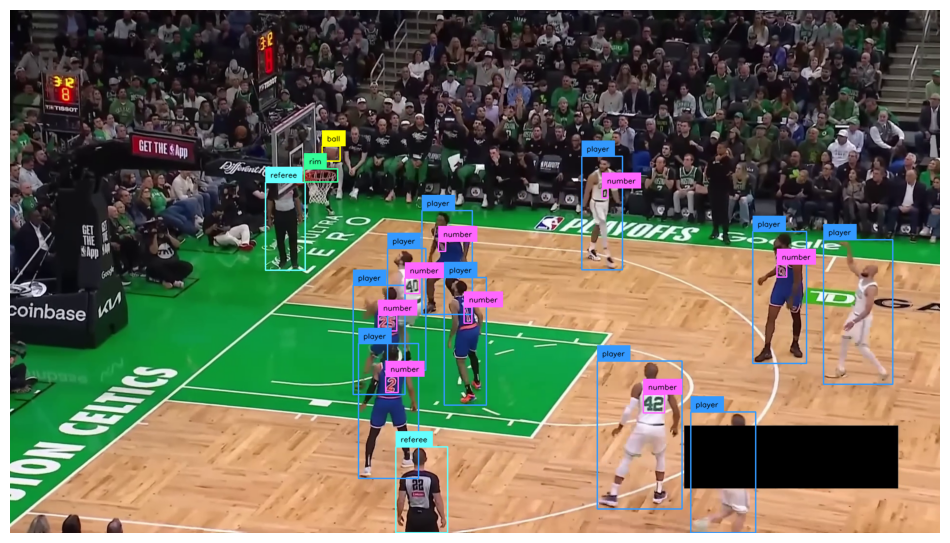

[{'event': 'START', 'frame': 121, 'type': 'LAYUP'}]


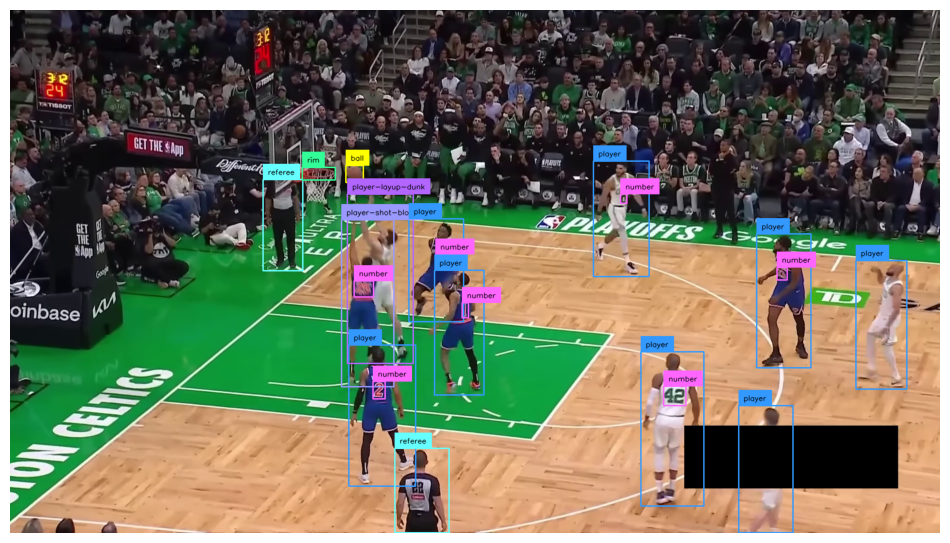

[{'event': 'MADE', 'frame': 135, 'type': 'LAYUP'}]


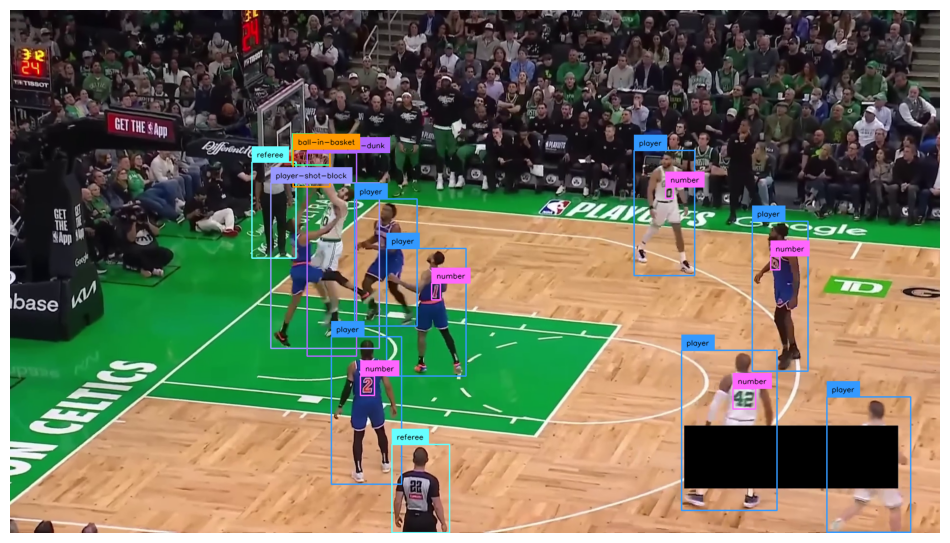

In [ ]:
BALL_IN_BASKET_CLASS_ID = 1
JUMP_SHOT_CLASS_ID = 5
LAYUP_DUNK_CLASS_ID = 6

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

shot_event_tracker = ShotEventTracker(
    reset_time_frames=int(video_info.fps * 1.7),
    minimum_frames_between_starts=int(video_info.fps * 0.5),
    cooldown_frames_after_made=int(video_info.fps * 0.5),
)

for frame_index, frame in enumerate(frame_generator):

    # we use a RF-DETR model to detect jump shot, layup, dunk and ball in basket

    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result)

    has_jump_shot = len(detections[detections.class_id == JUMP_SHOT_CLASS_ID]) > 0
    has_layup_dunk = len(detections[detections.class_id == LAYUP_DUNK_CLASS_ID]) > 0
    has_ball_in_basket = len(detections[detections.class_id == BALL_IN_BASKET_CLASS_ID]) > 0

    events = shot_event_tracker.update(
        frame_index=frame_index,
        has_jump_shot=has_jump_shot,
        has_layup_dunk=has_layup_dunk,
        has_ball_in_basket=has_ball_in_basket,
    )

    if events:
        print(events)

        annotated_frame = frame.copy()
        annotated_frame = box_annotator.annotate(
            scene=annotated_frame,
            detections=detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections)

        sv.plot_image(annotated_frame)

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>